<a href="https://colab.research.google.com/github/santana-robledo/Posgrado_Robotica_e_Inteligencia_Artificial/blob/main/Redes%20Neuronales%20Artificiales/Clasificador_Colores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from google.colab import files

Mounted at /content/drive


(np.float64(-0.5), np.float64(1919.5), np.float64(1919.5), np.float64(-0.5))

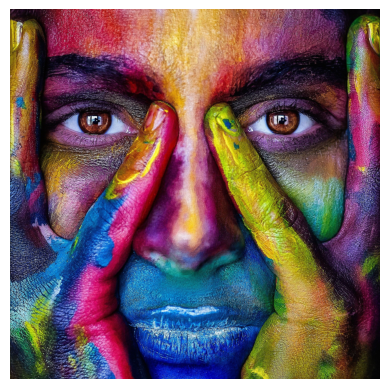

In [2]:
from google.colab import drive
drive.mount('/content/drive')
Imagen = cv2.imread('/content/drive/MyDrive/Redes Neuronales Artificiales 2026A/Imagen.jpg')
Imagen = cv2.cvtColor(Imagen, cv2.COLOR_BGR2RGB)

plt.imshow(Imagen)
plt.axis("off")

In [3]:
def tanh(x):
    return np.tanh(x)

def softmax(z):
    expZ = np.exp(z - np.max(z))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def cross_entropy(y, a):
    m = y.shape[1]
    return -np.sum(y*np.log(a+1e-8))/m

In [6]:
X = np.array([
[255,0,0],    # rojo
[200,30,20],
[180,40,40],

[0,0,255],    # azul
[30,30,200],
[40,60,220],

[0,255,0],    # verde
[20,200,30],
[30,220,40],

[255,255,0],    # amarillo
[220,200,40],
[200,180,60],

[255,0,255],    # magenta
[220,40,200],
[200,60,180],

[0,255,255],    # cian
[40,220,200],
[60,200,180],

[255,255,255],   # blanco
[240,240,240],
[220,220,220],

[0,0,0],         # negro
[20,20,20],
[40,40,40],

[139,69,19],     # café
[160,82,45],
[120,60,20]])



Y = np.array([
[1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0],
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0],
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0],
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0],
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1]
])

In [7]:
X = X / 255
X = X.T

n_x = X.shape[0]
n_y = Y.shape[0]
n_h1 = 16
n_h2 = 8
n_h3 = 8

In [10]:
w1=np.random.rand(n_h1,X.shape[0])*0.1
b1=np.zeros((n_h1, 1))
w2=np.random.rand(n_h2,n_h1)*0.1
b2=np.zeros((n_h2, 1))
w3=np.random.rand(n_h3,n_h2)*0.1
b3=np.zeros((n_h3, 1))
w4 = np.random.randn(n_y, n_h3) * 0.1
b4 = np.zeros((n_y, 1))
#solo un sesgo para nuestra salida

#Tasa de aprendizaje
alpha=0.3
iter=23000

for i in range(iter):

    #Forward Propagation
    Z1=np.dot(w1,X)+b1
    A1= np.tanh(Z1)

    Z2=np.dot(w2,A1)+b2
    A2= np.tanh(Z2)

    Z3=np.dot(w3,A2)+b3
    A3=np.tanh(Z3)

    Z4=np.dot(w4,A3)+b4
    A4=softmax(Z4)

    loss = cross_entropy(Y, A4)

    #BackPropagation

    dZ4 = A4 - Y
    dw4 = (1/X.shape[1]) * np.dot(dZ4, A3.T)
    db4 = (1/X.shape[1]) * np.sum(dZ4, axis=1, keepdims=True)

    dA3 = np.dot(w4.T, dZ4)
    dZ3 = (1 - np.power(A3,2)) * dA3
    dw3=(1/X.shape[1])*np.dot(dZ3,A2.T)
    db3=(1/X.shape[1]) *np.sum(dZ3,axis=1,keepdims=True)

    dA2=np.dot(w3.T,dZ3)
    dZ2= (1-np.power(A2,2))*dA2
    dW2= (1/X.shape[1])*np.dot(dZ2,A1.T)
    db2= (1/X.shape[1])*np.sum(dZ2,axis=1,keepdims=True)

    dA1=np.dot(w2.T,dZ2)
    dZ1=(1-np.power(A1,2))*dA1
    dW1=(1/X.shape[1])*np.dot(dZ1,X.T)
    db1= (1/X.shape[1])*np.sum(dZ1,axis=1,keepdims=True)

    ##Actualización de Parámetros del gradiente descendente
    w1-=alpha*dW1
    b1-=alpha*db1
    w2-=alpha*dW2
    b2-=alpha*db2
    w3-=alpha*dw3
    b3-=alpha*db3
    w4-=alpha*dw4
    b4-=alpha*db4

    if i % 100==0:
        print(f"Iteración: {i}   Perdida: {loss}")

Iteración: 0   Perdida: 2.197007820462337
Iteración: 100   Perdida: 2.102834484164001
Iteración: 200   Perdida: 1.4498413507231145
Iteración: 300   Perdida: 1.0796593973460236
Iteración: 400   Perdida: 0.8369391825999644
Iteración: 500   Perdida: 0.7664257647513516
Iteración: 600   Perdida: 0.6381032795007345
Iteración: 700   Perdida: 0.538886540926537
Iteración: 800   Perdida: 0.42467078646463685
Iteración: 900   Perdida: 0.32772272472091246
Iteración: 1000   Perdida: 0.31601629552204186
Iteración: 1100   Perdida: 0.1445485569739003
Iteración: 1200   Perdida: 0.06943008261262866
Iteración: 1300   Perdida: 0.04484509646350432
Iteración: 1400   Perdida: 0.032546216487293174
Iteración: 1500   Perdida: 0.025314016092624667
Iteración: 1600   Perdida: 0.020612759816353975
Iteración: 1700   Perdida: 0.017338738606288952
Iteración: 1800   Perdida: 0.01493969521601082
Iteración: 1900   Perdida: 0.013111866022896776
Iteración: 2000   Perdida: 0.011675804882405959
Iteración: 2100   Perdida: 0.01

In [14]:
def neurona_profunda(X):

    Z1 = np.dot(w1, X) + b1
    A1 = np.tanh(Z1)

    Z2 = np.dot(w2, A1) + b2
    A2 = np.tanh(Z2)

    Z3 = np.dot(w3, A2) + b3
    A3 = np.tanh(Z3)

    Z4 = np.dot(w4, A3) + b4
    A4 = softmax(Z4)

    clase = np.argmax(A4)

    colores = [
        "Rojo","Azul","Verde",
        "Amarillo","Magenta","Cian",
        "Blanco","Negro","Cafe"
    ]

    print("Probabilidades:", A4.ravel())
    print("Color:", colores[clase])

    return clase

In [15]:
color = np.array([250,0,250])
color = color.reshape(3,1)/255
neurona_profunda(color)

Probabilidades: [3.99742307e-06 1.13519413e-06 3.22397072e-09 9.08807447e-05
 9.99685404e-01 1.53259748e-04 6.52505074e-05 2.91486185e-13
 6.88260747e-08]
Color: Magenta


np.int64(4)

In [16]:
def predecir_color(pixel):

    X = pixel.reshape(3,1)/255

    Z1 = np.dot(w1, X) + b1
    A1 = np.tanh(Z1)

    Z2 = np.dot(w2, A1) + b2
    A2 = np.tanh(Z2)

    Z3 = np.dot(w3, A2) + b3
    A3 = np.tanh(Z3)

    Z4 = np.dot(w4, A3) + b4
    A4 = softmax(Z4)

    clase = np.argmax(A4)

    return clase

In [17]:
colores_rgb = np.array([
[255,0,0],      # rojo
[0,0,255],      # azul
[0,255,0],      # verde
[255,255,0],    # amarillo
[255,0,255],    # magenta
[0,255,255],    # cian
[255,255,255],  # blanco
[0,0,0],        # negro
[139,69,19]     # cafe
])

In [18]:
imagen_clasificada = Imagen.copy()

alto, ancho, _ = Imagen.shape

In [19]:
for i in range(alto):
    for j in range(ancho):

        pixel = Imagen[i,j]

        clase = predecir_color(pixel)

        imagen_clasificada[i,j] = colores_rgb[clase]

(np.float64(-0.5), np.float64(1919.5), np.float64(1919.5), np.float64(-0.5))

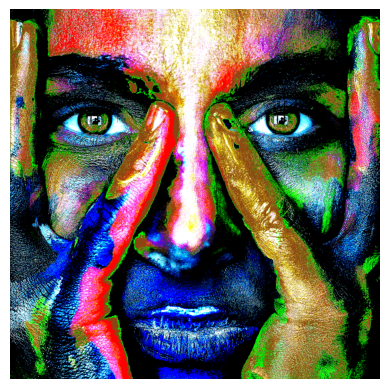

In [20]:
plt.imshow(imagen_clasificada)
plt.axis("off")